# IMDB Movie Reviews Sentiment Classifier using CNN

## 23BAI1589 - Yashvanth Karunakaran

### AIM
To design and implement a Convolutional Neural Network (CNN) to classify sentiment in movie reviews as positive or negative using the IMDB dataset.

### 1. Data Preparation

#### Loading Dataset

In [67]:
from tensorflow.keras.datasets import imdb

VOCAB_SIZE=10000
MAX_SEQ_LEN=500
EMBEDDING_DIM=100

(X_train,y_train),(X_test,y_test)=imdb.load_data(num_words=VOCAB_SIZE)

/media/yashix/New Volume1/Speech/Lab/myenv/lib/python3.12/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


#### Checking how X_train Looks

In [68]:
X_train

array([list([1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]),
       list([1, 194, 1153, 194, 8255, 78, 228,

#### Plotting the Distribution of Sequence Lengths

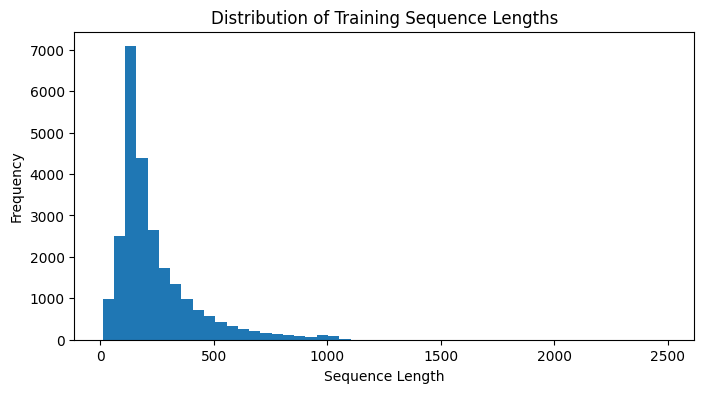

In [69]:
import matplotlib.pyplot as plt

train_lengths=[len(seq) for seq in X_train]
test_lengths=[len(seq) for seq in X_test]

plt.figure(figsize=(8,4))
plt.hist(train_lengths,bins=50)
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')
plt.title('Distribution of Training Sequence Lengths')
plt.show()

#### Checking how Target Looks

In [70]:
y_train

array([1, 0, 0, ..., 0, 1, 0], shape=(25000,))

#### Checking distribution of positive and negative classes

In [71]:
import numpy as np
import pandas as pd

labels,counts=np.unique(y_train,return_counts=True)

pd.DataFrame(labels,counts)

,0
12500,0
12500,1


#### Creating word to index and index to word mappings

In [72]:
word_idx=imdb.get_word_index()
idx_word={val:key for key,val in word_idx.items()}

#### Checking how a sentences looks

In [73]:
X_train[0][:20]

[1,
 14,
 22,
 16,
 43,
 530,
 973,
 1622,
 1385,
 65,
 458,
 4468,
 66,
 3941,
 4,
 173,
 36,
 256,
 5,
 25]

#### Replacing the word ids in the sentence with actual word
```subtracting 3 because first 0 is <PAD>, 1 is <START> and 2 is <UNK>```

so actual words start from index 3

In [74]:
sent = [idx_word.get(i-3,'-') for i in X_train[0]]
sent[:20]

['-',
 'this',
 'film',
 'was',
 'just',
 'brilliant',
 'casting',
 'location',
 'scenery',
 'story',
 'direction',
 "everyone's",
 'really',
 'suited',
 'the',
 'part',
 'they',
 'played',
 'and',
 'you']

#### Sequence padding
Training and test sequences are padded and truncated to a fixed length of 500 so that all input reviews have the same size before being fed into the neural network.

In [75]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train_padded=pad_sequences(X_train,maxlen=MAX_SEQ_LEN,padding='post',truncating='post')
X_test_padded=pad_sequences(X_test,maxlen=MAX_SEQ_LEN,padding='post',truncating='post')

#### Train-validation split of 80:20

In [76]:
from sklearn.model_selection import train_test_split

X_train_final,X_val,y_train_final,y_val=train_test_split(X_train_padded,y_train,test_size=0.2,random_state=42,stratify=y_train)

### 2. Model Architecture
CNN-based sentiment classification model is built using an embedding layer (with optional pre-trained embeddings), multiple 1D convolution layers with different filter sizes to capture n-gram features, global max pooling, concatenation, dropout for regularization, and fully connected layers ending with a sigmoid output for binary classification.

In [77]:
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D,Dense,Dropout,Concatenate,Input
from tensorflow.keras.models import Sequential,Model

def build_model(vocab_size=VOCAB_SIZE,embedding_dim=EMBEDDING_DIM,max_length=MAX_SEQ_LEN,num_filters=128,filter_sizes=[3,4,5],dropout_rate=0.5,embedding_matrix=None,trainable_embedding=True):
    
    inputs=Input(shape=(MAX_SEQ_LEN,),name='input')

    if embedding_matrix is not None:
        embedding=Embedding(input_dim=vocab_size,output_dim=embedding_matrix.shape[1],input_length=max_length,
                            weights=[embedding_matrix],trainable=trainable_embedding,name='embedding')(inputs)
    else:
        embedding=Embedding(input_dim=vocab_size,output_dim=embedding_dim,input_length=max_length,name='embedding')(inputs)

    conv_blocks=[]

    for size in filter_sizes:
        conv=Conv1D(filters=num_filters,kernel_size=size,activation='relu',name=f'conv_{size}')(embedding)

        pool=GlobalMaxPooling1D(name=f'maxpool_{size}')(conv)
        conv_blocks.append(pool)

    merged=Concatenate(name='concatenate')(conv_blocks)

    dropout1=Dropout(dropout_rate,name='dropout_1')(merged)

    dense=Dense(128,activation='relu',name='dense')(dropout1)

    dropout2=Dropout(dropout_rate,name='dropout_2')(dense)

    outputs=Dense(1,activation='sigmoid',name='output')(dropout2)

    model=Model(inputs=inputs,outputs=outputs,name='CNN_Sentiment_Classifier')
    
    return model

### 3. Model Training

#### Model Compiling and summary

In [78]:
from tensorflow.keras.optimizers import Adam

model=build_model()

model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])

model.summary()

/media/yashix/New Volume1/Speech/Lab/myenv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "CNN_Sentiment_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 500)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 500, 100)  │  1,000,000 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_3 (Conv1D)     │ (None, 498, 128)  │     38,528 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_4 (Conv1D)     │ (None, 497, 128)  │     51,328 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_5 (Conv1D)     │ (None, 496, 128)  │     64,128 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_3           │ (None, 128)       │          0 │ conv_3[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_4           │ (None, 128)       │          0 │ conv_4[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_5           │ (None, 128)       │          0 │ conv_5[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ maxpool_3[0][0],  │
│ (Concatenate)       │                   │            │ maxpool_4[0][0],  │
│                     │                   │            │ maxpool_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 384)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     49,280 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        129 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,203,393 (4.59 MB)

 Trainable params: 1,203,393 (4.59 MB)

...

Model: "CNN_Sentiment_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 500)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 500, 100)  │  1,000,000 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_3 (Conv1D)     │ (None, 498, 128)  │     38,528 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_4 (Conv1D)     │ (None, 497, 128)  │     51,328 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_5 (Conv1D)     │ (None, 496, 128)  │     64,128 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_3           │ (None, 128)       │          0 │ conv_3[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_4           │ (None, 128)       │          0 │ conv_4[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_5           │ (None, 128)       │          0 │ conv_5[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ maxpool_3[0][0],  │
│ (Concatenate)       │                   │            │ maxpool_4[0][0],  │
│                     │                   │            │ maxpool_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 384)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     49,280 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        129 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,203,393 (4.59 MB)

 Trainable params: 1,203,393 (4.59 MB)

 Non-trainable params: 0 (0.00 B)

#### Training callbacks
Early stopping is used to halt training when validation loss stops improving, while learning rate reduction dynamically lowers the learning rate when progress plateaus, helping improve convergence and prevent overfitting.

In [79]:
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau

early_stopping=EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True,verbose=1)

reduce_lr=ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=2,min_lr=0.00001,verbose=1)

callbacks=[early_stopping,reduce_lr]

#### Model Training
batch size: 64
epochs: 10
validation data to monitor overfitting

In [80]:
history=model.fit(X_train_final,y_train_final,batch_size=64,epochs=10,validation_data=(X_val,y_val),callbacks=callbacks,verbose=1)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 134ms/step - accuracy: 0.7049 - loss: 0.5365 - val_accuracy: 0.8534 - val_loss: 0.3442 - learning_rate: 0.0010
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 135ms/step - accuracy: 0.8808 - loss: 0.2952 - val_accuracy: 0.8784 - val_loss: 0.2876 - learning_rate: 0.0010
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 132ms/step - accuracy: 0.9333 - loss: 0.1781 - val_accuracy: 0.8842 - val_loss: 0.2830 - learning_rate: 0.0010
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 147ms/step - accuracy: 0.9645 - loss: 0.1015 - val_accuracy: 0.8802 - val_loss: 0.3401 - learning_rate: 0.0010
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.9829 - loss: 0.0537
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 134ms/step - accuracy: 0.9808 - loss: 0.0569 - val_accuracy: 0.8808 - val_loss: 0.4132 - learning_rate: 0.0010
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 132ms/step - accuracy: 0.992

### 4. Evaluation

#### Training vs validation accuracy plot

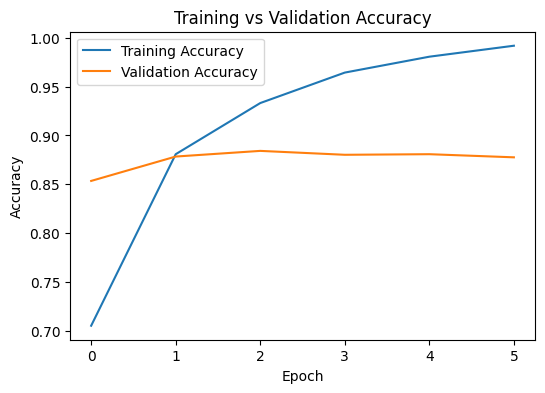

In [81]:
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

#### Training vs validation loss plot

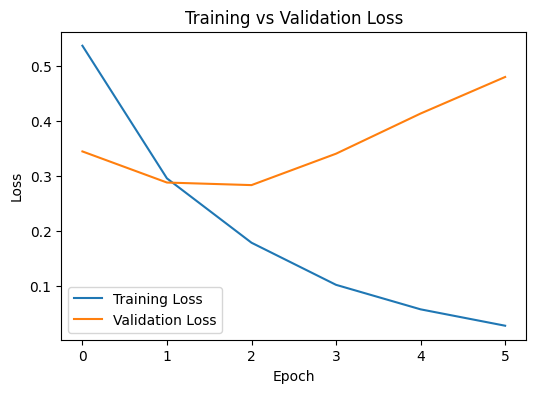

In [82]:
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

#### Best validation performance
highest validation accuracy achieved during training with epoch to evaluate model's best performance on unseen data

In [ ]:
best_val_accuracy=max(history.history['val_accuracy'])
best_epoch=history.history['val_accuracy'].index(best_val_accuracy) + 1
print(f"Best Validation Accuracy: {best_val_accuracy:.4f} at Epoch {best_epoch}")

Best Validation Accuracy: 0.8842 at Epoch 3


#### Model Evaluation on Test Data

In [84]:
test_loss,test_accuracy=model.evaluate(X_test_padded,y_test,verbose=1)

print("Test Loss:",test_loss)
print(f"Test Accuracy: {test_accuracy:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.8871 - loss: 0.2759
Test Loss: 0.2758795917034149
Test Accuracy: 0.8871


#### Prediction and Thresholding
trained model generates probability scores for the test data, which are then converted into binary class labels using a threshold of 0.5 for sentiment classification

In [85]:
y_pred_proba=model.predict(X_test_padded,batch_size=128)
y_pred=(y_pred_proba>0.5).astype(int).flatten()

196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step


#### Confusion matrix and evaluation metrics

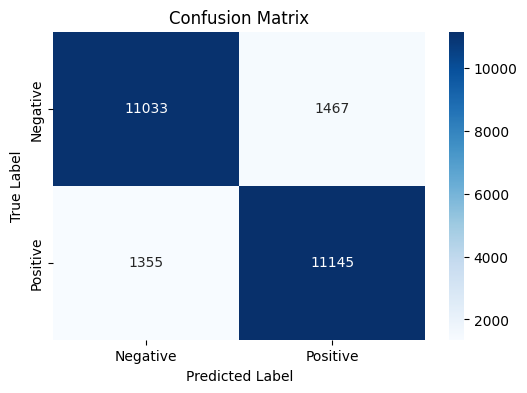

In [86]:
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score
import seaborn as sns

cm=confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['Negative','Positive'],yticklabels=['Negative','Positive'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [87]:
print(f"Precision Score: {precision_score(y_test,y_pred):.4f}")
print(f"Recall Score: {accuracy_score(y_test,y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test,y_pred):.4f}")

Precision Score: 0.8837
Recall Score: 0.8871
F1 Score: 0.8876


In [88]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred,target_names=['Negative','Positive']))

              precision    recall  f1-score   support

    Negative       0.89      0.88      0.89     12500
    Positive       0.88      0.89      0.89     12500

    accuracy                           0.89     25000
   macro avg       0.89      0.89      0.89     25000
weighted avg       0.89      0.89      0.89     25000



#### Sample predictions
testing on custom reviews

In [89]:
def predict_sentiment(text):
    words=text.lower().split()
    sequence=[]
    for word in words:
        idx=word_idx.get(word,0)
        if idx>0 and idx+3<10000:
            sequence.append(idx+3)
    
    if len(sequence)==0:
        sequence=[0]
    
    processed=pad_sequences([sequence],maxlen=MAX_SEQ_LEN,padding='post',truncating='post')
    prediction=model.predict(processed)[0][0]
    
    sentiment="Positive" if prediction>0.5 else "Negative"
    confidence=prediction if prediction>0.5 else 1-prediction
    
    return sentiment,confidence

Testing a sample review for both negative and positive class

In [90]:
review="This movie was a captivating masterpiece!"

sentiment, confidence = predict_sentiment(review)

print(f"Sentiment Predicted: {sentiment}")
print(f"Confidence Score: {confidence:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Sentiment Predicted: Positive
Confidence Score: 0.5142


In [91]:
review="Jananayagan movie is worst and a flop of Vijay's Career!"

sentiment, confidence = predict_sentiment(review)

print(f"Sentiment Predicted: {sentiment}")
print(f"Confidence Score: {confidence:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Sentiment Predicted: Negative
Confidence Score: 0.9905


### 5. Optimization

#### Hyperparameter Tuning
Adjusting Embedding dimensions, filter sizes, dropout rate

In [94]:
hp_configs = [
    {"embedding_dim": 64, 
     "filter_sizes": [3, 4, 5], 
     "num_filters": 64, 
     "dropout_rate": 0.3},
    {"embedding_dim": 100, 
     "filter_sizes": [3, 4, 5], 
     "num_filters": 128, 
     "dropout_rate": 0.5},
    {"embedding_dim": 128, 
     "filter_sizes": [2, 3, 5], 
     "num_filters": 128, 
     "dropout_rate": 0.5},
]

#### Tuning and Performance Comparison
Each model is evaluated using validation and test metrics, and the results are collected and compared in a tabular format

In [95]:
import pandas as pd

results=[]

for i,cfg in enumerate(hp_configs):
    m = build_model(
        embedding_dim=cfg["embedding_dim"],
        num_filters=cfg["num_filters"],
        filter_sizes=cfg["filter_sizes"],
        dropout_rate=cfg["dropout_rate"]
    )

    m.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy',metrics=['accuracy'])

    es=EarlyStopping(monitor='val_loss',patience=3, restore_best_weights=True,verbose=0)
    r_lr=ReduceLROnPlateau(monitor='val_loss', factor=0.5,patience=2,min_lr=1e-5,verbose=0)

    hist=m.fit(X_train_final,y_train_final,batch_size=64,epochs=10,validation_data=(X_val,y_val),callbacks=[es,r_lr],verbose=0)

    val_acc=max(hist.history['val_accuracy'])
    val_loss=min(hist.history['val_loss'])
    test_loss_i,test_acc_i=m.evaluate(X_test_padded, y_test, verbose=0)

    results.append({
        "Config": i + 1,
        "Embedding Dim":cfg["embedding_dim"],
        "Filter Sizes":str(cfg["filter_sizes"]),
        "Num Filters":cfg["num_filters"],
        "Dropout Rate":cfg["dropout_rate"],
        "Best Val Acc":round(val_acc, 4),
        "Best Val Loss":round(val_loss, 4),
        "Test Acc":round(test_acc_i, 4),
        "Test Loss":round(test_loss_i, 4),
    })

    print(f"Config: {i} | Val Acc: {val_acc:.4f} | Test Acc: {test_acc_i:.4f}")

results_df = pd.DataFrame(results)
results_df

/media/yashix/New Volume1/Speech/Lab/myenv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Config: 0 | Val Acc: 0.8862 | Test Acc: 0.8826
Config: 1 | Val Acc: 0.8868 | Test Acc: 0.8854
Config: 2 | Val Acc: 0.8894 | Test Acc: 0.8877


,Config,Embedding Dim,Filter Sizes,Num Filters,Dropout Rate,Best Val Acc,Best Val Loss,Test Acc,Test Loss
0,1,64,"[3, 4, 5]",64,0.3,0.8862,0.3013,0.8826,0.2867
1,2,100,"[3, 4, 5]",128,0.5,0.8868,0.2752,0.8854,0.2749
2,3,128,"[2, 3, 5]",128,0.5,0.8894,0.2745,0.8877,0.2714


#### Checking the Best model configurations
highlighting the optimal embedding dimension, filter sizes, number of filters, dropout rate, and overall test performance.

In [96]:
best_idx = max(range(len(results)),key=lambda i: results[i]['Test Acc'])
best_cfg = hp_configs[best_idx]

print(f"Best Configuration:")
print(f"Embedding Dim : {best_cfg['embedding_dim']}")
print(f"Filter Sizes  : {best_cfg['filter_sizes']}")
print(f"Num Filters   : {best_cfg['num_filters']}")
print(f"Dropout Rate  : {best_cfg['dropout_rate']}")
print(f"Test Accuracy : {results[best_idx]['Test Acc']:.4f}")

Best Configuration:
Embedding Dim : 128
Filter Sizes  : [2, 3, 5]
Num Filters   : 128
Dropout Rate  : 0.5
Test Accuracy : 0.8877


#### Best Model Construction
CNN model is rebuilt using the best-performing hyperparameter configuration

In [97]:
best_model = build_model(
    embedding_dim=best_cfg["embedding_dim"],
    num_filters=best_cfg["num_filters"],
    filter_sizes=best_cfg["filter_sizes"],
    dropout_rate=best_cfg["dropout_rate"]
)

best_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

best_model.summary()

/media/yashix/New Volume1/Speech/Lab/myenv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "CNN_Sentiment_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 500)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 500, 128)  │  1,280,000 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_2 (Conv1D)     │ (None, 499, 128)  │     32,896 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_3 (Conv1D)     │ (None, 498, 128)  │     49,280 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_5 (Conv1D)     │ (None, 496, 128)  │     82,048 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_2           │ (None, 128)       │          0 │ conv_2[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_3           │ (None, 128)       │          0 │ conv_3[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_5           │ (None, 128)       │          0 │ conv_5[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ maxpool_2[0][0],  │
│ (Concatenate)       │                   │            │ maxpool_3[0][0],  │
│                     │                   │            │ maxpool_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 384)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     49,280 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        129 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,493,633 (5.70 MB)

 Trainable params: 1,493,633 (5.70 MB)

 Non-trainable params: 0 (0.00 B)

#### Training the best model

In [98]:
best_history = best_model.fit(X_train_final,y_train_final,batch_size=64,epochs=10,validation_data=(X_val,y_val),
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1)
    ],
    verbose=1
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 52s 163ms/step - accuracy: 0.7290 - loss: 0.5141 - val_accuracy: 0.8596 - val_loss: 0.3310 - learning_rate: 0.0010
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 52s 166ms/step - accuracy: 0.8851 - loss: 0.2825 - val_accuracy: 0.8858 - val_loss: 0.2702 - learning_rate: 0.0010
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 51s 161ms/step - accuracy: 0.9347 - loss: 0.1720 - val_accuracy: 0.8910 - val_loss: 0.2855 - learning_rate: 0.0010
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.9697 - loss: 0.0863
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
313/313 ━━━━━━━━━━━━━━━━━━━━ 50s 158ms/step - accuracy: 0.9668 - loss: 0.0944 - val_accuracy: 0.8862 - val_loss: 0.3278 - learning_rate: 0.0010
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 49s 158ms/step - accuracy: 0.9865 - loss: 0.0440 - val_accuracy: 0.8866 - val_loss: 0.4014 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights from the end of the 

In [99]:
best_test_loss, best_test_acc = best_model.evaluate(X_test_padded, y_test, verbose=1)
print(f"\nBest Model Test Accuracy: {best_test_acc:.4f}")
print(f"Best Model Test Loss: {best_test_loss:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.8905 - loss: 0.2653

Best Model Test Accuracy: 0.8905
Best Model Test Loss: 0.2653


#### Evaluation of Best Tuned Model


196/196 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step


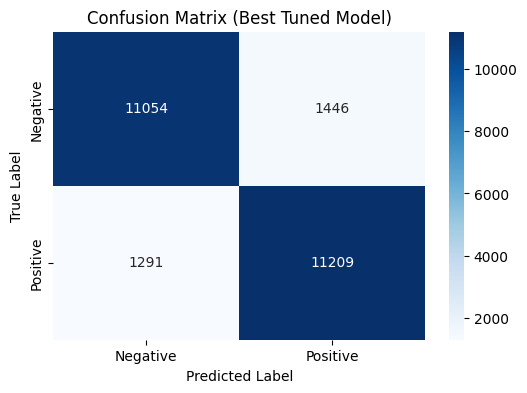

In [100]:
y_pred_best_proba = best_model.predict(X_test_padded, batch_size=128)
y_pred_best = (y_pred_best_proba > 0.5).astype(int).flatten()

cm_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Best Tuned Model)")
plt.show()

In [101]:
print(classification_report(y_test, y_pred_best,target_names=['Negative', 'Positive']))

              precision    recall  f1-score   support

    Negative       0.90      0.88      0.89     12500
    Positive       0.89      0.90      0.89     12500

    accuracy                           0.89     25000
   macro avg       0.89      0.89      0.89     25000
weighted avg       0.89      0.89      0.89     25000



#### Pre Trained Embeddings
Experimenting with GloVe Embeddings

#### Downloading GloVe Embeddings

In [102]:
import urllib.request
import os

GLOVE_DIR="/media/yashix/New Volume1/Speech/Lab/glove"
GLOVE_ZIP=os.path.join(GLOVE_DIR,"glove.6B.zip")
GLOVE_FILE=os.path.join(GLOVE_DIR,"glove.6B.100d.txt")

os.makedirs(GLOVE_DIR, exist_ok=True)

if not os.path.exists(GLOVE_ZIP):
    urllib.request.urlretrieve("https://nlp.stanford.edu/data/glove.6B.zip",GLOVE_ZIP)

#### Extracting the downloaded GloVe embeddings

In [103]:
import zipfile

with zipfile.ZipFile(GLOVE_ZIP,'r') as z:
    z.extract('glove.6B.100d.txt',GLOVE_DIR)

#### Loading GloVe Embeddings
loading pre-trained word vectors into a dictionary, mapping each word to its corresponding numerical embedding

In [104]:
GLOVE_DIM = 100

glove_embeddings = {}
with open(GLOVE_FILE,'r',encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split()
        word = parts[0]
        vector = np.array(parts[1:], dtype='float32')
        glove_embeddings[word] = vector

print(f"Loaded {len(glove_embeddings)} GloVe word vectors.")
print(f"'movie': {glove_embeddings['movie'][:5]}...")

Loaded 400000 GloVe word vectors.
'movie': [ 0.38251  0.14821  0.60601 -0.51533  0.43992]...


#### Creating the Embedding Matrix
embedding matrix is constructed by mapping the dataset vocabulary to pre-trained GloVe vectors. Words not present in GloVe are assigned zero vectors

In [105]:
embedding_matrix=np.zeros((VOCAB_SIZE,GLOVE_DIM))

found=0
not_found=0

for word,idx in word_idx.items():
    if idx<VOCAB_SIZE:
        vec=glove_embeddings.get(word)
        if vec is not None:
            embedding_matrix[idx]=vec
            found+=1
        else:
            not_found+=1

print(f"Words found in GloVe: {found}")
print(f"Words NOT found (zero vector): {not_found}")
print(f"Embedding matrix shape: {embedding_matrix.shape}")

Words found in GloVe: 9796
Words NOT found (zero vector): 203
Embedding matrix shape: (10000, 100)


#### GloVe-Based Model with Frozen Embeddings
CNN sentiment classification model is built using pre-trained GloVe embeddings with the embedding layer frozen

In [106]:
glove_model_frozen=build_model(
    embedding_matrix=embedding_matrix,
    trainable_embedding=False,
    num_filters=128,
    filter_sizes=[3,4,5],
    dropout_rate=0.5
)

glove_model_frozen.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy', metrics=['accuracy'])
glove_model_frozen.summary()

/media/yashix/New Volume1/Speech/Lab/myenv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "CNN_Sentiment_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 500)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 500, 100)  │  1,000,000 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_3 (Conv1D)     │ (None, 498, 128)  │     38,528 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_4 (Conv1D)     │ (None, 497, 128)  │     51,328 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_5 (Conv1D)     │ (None, 496, 128)  │     64,128 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_3           │ (None, 128)       │          0 │ conv_3[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_4           │ (None, 128)       │          0 │ conv_4[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_5           │ (None, 128)       │          0 │ conv_5[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ maxpool_3[0][0],  │
│ (Concatenate)       │                   │            │ maxpool_4[0][0],  │
│                     │                   │            │ maxpool_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 384)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     49,280 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        129 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,203,393 (4.59 MB)

 Trainable params: 203,393 (794.50 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

#### GloVe embedding Frozen Model Training

In [107]:
glove_frozen_history=glove_model_frozen.fit(
    X_train_final,y_train_final,
    batch_size=64,epochs=10,
    validation_data=(X_val,y_val),
    callbacks=[
        EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True,verbose=1),
        ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=2,min_lr=1e-5,verbose=1)
    ],
    verbose=1
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 97ms/step - accuracy: 0.5013 - loss: 0.7194 - val_accuracy: 0.5040 - val_loss: 0.6928 - learning_rate: 0.0010
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 95ms/step - accuracy: 0.5090 - loss: 0.6937 - val_accuracy: 0.5474 - val_loss: 0.6925 - learning_rate: 0.0010
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 98ms/step - accuracy: 0.5128 - loss: 0.6929 - val_accuracy: 0.5220 - val_loss: 0.6907 - learning_rate: 0.0010
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 98ms/step - accuracy: 0.5421 - loss: 0.6864 - val_accuracy: 0.6148 - val_loss: 0.6691 - learning_rate: 0.0010
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 95ms/step - accuracy: 0.6143 - loss: 0.6486 - val_accuracy: 0.7044 - val_loss: 0.5950 - learning_rate: 0.0010
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 96ms/step - accuracy: 0.6952 - loss: 0.5760 - val_accuracy: 0.7534 - val_loss: 0.5143 - learning_rate: 0.0010
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 95ms/step - accuracy: 0.7546 - l

#### Evaluation of Frozen GloVe Model

In [108]:
frozen_test_loss,frozen_test_acc=glove_model_frozen.evaluate(X_test_padded,y_test)
print(f"\nGloVe (Frozen) Test Accuracy: {frozen_test_acc:.4f}")
print(f"GloVe (Frozen) Test Loss: {frozen_test_loss:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.7958 - loss: 0.4414

GloVe (Frozen) Test Accuracy: 0.7958
GloVe (Frozen) Test Loss: 0.4414


#### GloVe-Based Model with Fine-Tuned Embeddings
CNN sentiment classification model is constructed using pre-trained GloVe embeddings with the embedding layer set as trainable, allowing the word vectors to be fine-tuned during training

In [109]:
glove_model_finetune = build_model(
    embedding_matrix=embedding_matrix,
    trainable_embedding=True,
    num_filters=128,
    filter_sizes=[3, 4, 5],
    dropout_rate=0.5
)

glove_model_finetune.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
glove_model_finetune.summary()

Model: "CNN_Sentiment_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 500)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 500, 100)  │  1,000,000 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_3 (Conv1D)     │ (None, 498, 128)  │     38,528 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_4 (Conv1D)     │ (None, 497, 128)  │     51,328 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_5 (Conv1D)     │ (None, 496, 128)  │     64,128 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_3           │ (None, 128)       │          0 │ conv_3[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_4           │ (None, 128)       │          0 │ conv_4[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_5           │ (None, 128)       │          0 │ conv_5[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ maxpool_3[0][0],  │
│ (Concatenate)       │                   │            │ maxpool_4[0][0],  │
│                     │                   │            │ maxpool_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 384)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     49,280 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        129 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,203,393 (4.59 MB)

 Trainable params: 1,203,393 (4.59 MB)

 Non-trainable params: 0 (0.00 B)

#### GloVe fine tuned embedding Model Training

In [110]:
glove_finetune_history = glove_model_finetune.fit(
    X_train_final, y_train_final,
    batch_size=64, epochs=10,
    validation_data=(X_val, y_val),
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1)
    ],
    verbose=1
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 143ms/step - accuracy: 0.5087 - loss: 0.7157 - val_accuracy: 0.5048 - val_loss: 0.6930 - learning_rate: 0.0010
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 136ms/step - accuracy: 0.5217 - loss: 0.6925 - val_accuracy: 0.6186 - val_loss: 0.6821 - learning_rate: 0.0010
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 143ms/step - accuracy: 0.6320 - loss: 0.6315 - val_accuracy: 0.7202 - val_loss: 0.5365 - learning_rate: 0.0010
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 147ms/step - accuracy: 0.7796 - loss: 0.4673 - val_accuracy: 0.8200 - val_loss: 0.3859 - learning_rate: 0.0010
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 149ms/step - accuracy: 0.8615 - loss: 0.3336 - val_accuracy: 0.8494 - val_loss: 0.3320 - learning_rate: 0.0010
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 151ms/step - accuracy: 0.9085 - loss: 0.2347 - val_accuracy: 0.8620 - val_loss: 0.3277 - learning_rate: 0.0010
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 149ms/step - accuracy: 0.9

#### Evaluation of Fine-Tuned GloVe Model

In [111]:
finetune_test_loss, finetune_test_acc = glove_model_finetune.evaluate(X_test_padded, y_test, verbose=1)
print(f"\nGloVe (Fine-tuned) Test Accuracy: {finetune_test_acc:.4f}")
print(f"GloVe (Fine-tuned) Test Loss: {finetune_test_loss:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.8616 - loss: 0.3338

GloVe (Fine-tuned) Test Accuracy: 0.8616
GloVe (Fine-tuned) Test Loss: 0.3338


#### Model Performance Comparison

In [112]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Learned Embedding (Baseline)", "GloVe Frozen", "GloVe Fine-tuned"],
    "Test Accuracy": [
        round(best_test_acc, 4),
        round(frozen_test_acc, 4),
        round(finetune_test_acc, 4)
    ],
    "Test Loss": [
        round(best_test_loss, 4),
        round(frozen_test_loss, 4),
        round(finetune_test_loss, 4)
    ]
})

comparison

,Model,Test Accuracy,Test Loss
0,Learned Embedding (Baseline),0.8905,0.2653
1,GloVe Frozen,0.7958,0.4414
2,GloVe Fine-tuned,0.8616,0.3338


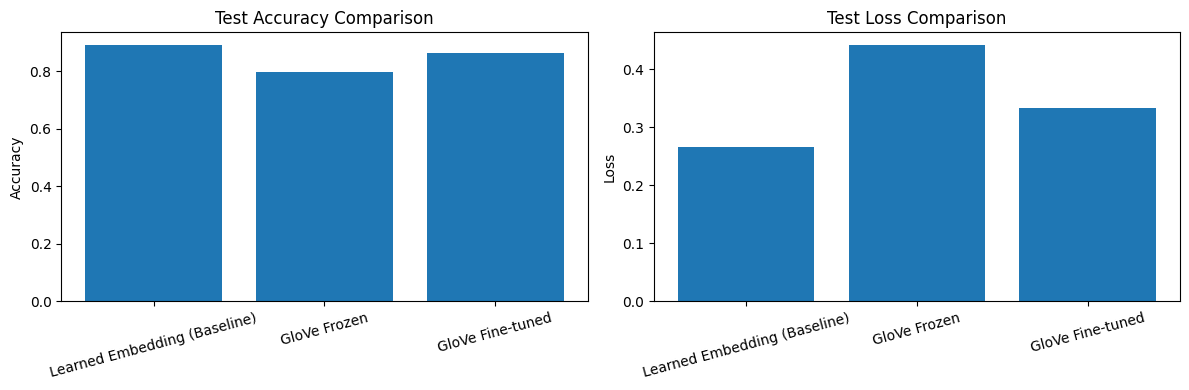

In [113]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

models = comparison["Model"]

axes[0].bar(models, comparison["Test Accuracy"])
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Test Accuracy Comparison")
axes[0].tick_params(axis='x',rotation=15)

axes[1].bar(models, comparison["Test Loss"])
axes[1].set_ylabel("Loss")
axes[1].set_title("Test Loss Comparison")
axes[1].tick_params(axis='x',rotation=15)

plt.tight_layout()
plt.show()

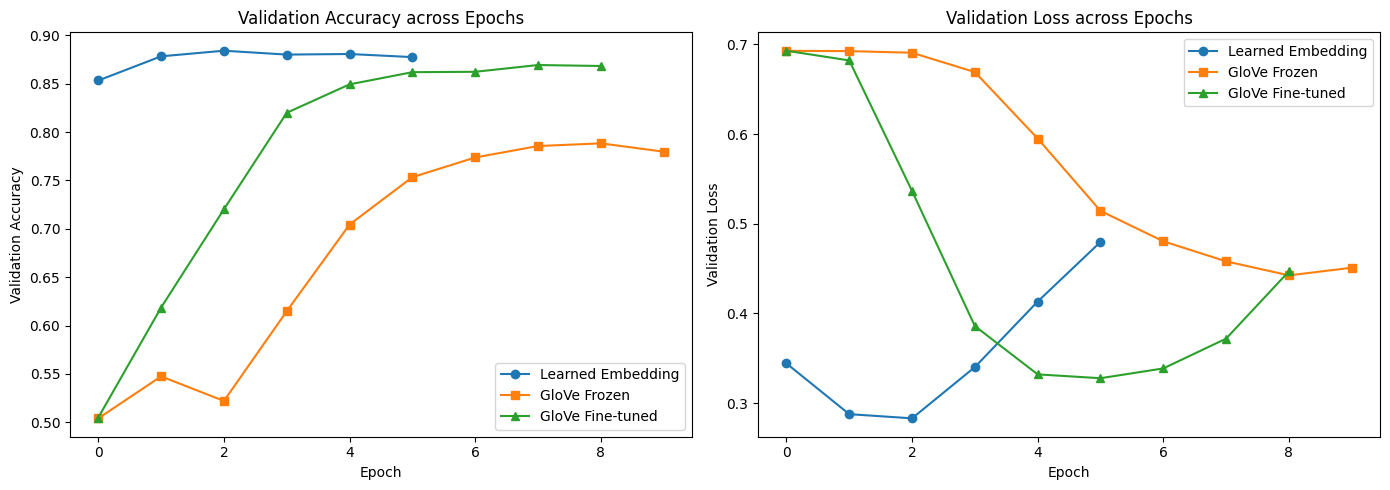

In [114]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['val_accuracy'], label='Learned Embedding', marker='o')
axes[0].plot(glove_frozen_history.history['val_accuracy'], label='GloVe Frozen', marker='s')
axes[0].plot(glove_finetune_history.history['val_accuracy'], label='GloVe Fine-tuned', marker='^')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Validation Accuracy")
axes[0].set_title("Validation Accuracy across Epochs")
axes[0].legend()

axes[1].plot(history.history['val_loss'], label='Learned Embedding', marker='o')
axes[1].plot(glove_frozen_history.history['val_loss'], label='GloVe Frozen', marker='s')
axes[1].plot(glove_finetune_history.history['val_loss'], label='GloVe Fine-tuned', marker='^')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Loss")
axes[1].set_title("Validation Loss across Epochs")
axes[1].legend()

plt.tight_layout()
plt.show()

#### Regularization
Adding L2 regularization and increasing dropout rate to 0.6 to avoid overfitting to certain extent

In [115]:
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D,Dense,Dropout,Concatenate,Input
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.regularizers import l2

def build_model(vocab_size=VOCAB_SIZE,embedding_dim=EMBEDDING_DIM,max_length=MAX_SEQ_LEN,num_filters=128,filter_sizes=[3,4,5],dropout_rate=0.6,embedding_matrix=None,trainable_embedding=True,l2_lambda=1e-4):
    
    inputs=Input(shape=(MAX_SEQ_LEN,),name='input')

    if embedding_matrix is not None:
        embedding=Embedding(input_dim=vocab_size,output_dim=embedding_matrix.shape[1],input_length=max_length,
                            weights=[embedding_matrix],trainable=trainable_embedding,name='embedding')(inputs)
    else:
        embedding=Embedding(input_dim=vocab_size,output_dim=embedding_dim,input_length=max_length,name='embedding')(inputs)

    conv_blocks=[]

    for size in filter_sizes:
        conv=Conv1D(filters=num_filters,kernel_size=size,activation='relu',kernel_regularizer=l2(l2_lambda),name=f'conv_{size}')(embedding)

        pool=GlobalMaxPooling1D(name=f'maxpool_{size}')(conv)
        conv_blocks.append(pool)

    merged=Concatenate(name='concatenate')(conv_blocks)

    dropout1=Dropout(dropout_rate,name='dropout_1')(merged)

    dense=Dense(128,activation='relu',kernel_regularizer=l2(l2_lambda),name='dense')(dropout1)

    dropout2=Dropout(dropout_rate,name='dropout_2')(dense)

    outputs=Dense(1,activation='sigmoid',name='output')(dropout2)

    model=Model(inputs=inputs,outputs=outputs,name='CNN_Sentiment_Classifier')
    
    return model

#### Regularized Model Compiling and summary

In [116]:
model=build_model()

model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])

model.summary()

/media/yashix/New Volume1/Speech/Lab/myenv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "CNN_Sentiment_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 500)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 500, 100)  │  1,000,000 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_3 (Conv1D)     │ (None, 498, 128)  │     38,528 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_4 (Conv1D)     │ (None, 497, 128)  │     51,328 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_5 (Conv1D)     │ (None, 496, 128)  │     64,128 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_3           │ (None, 128)       │          0 │ conv_3[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_4           │ (None, 128)       │          0 │ conv_4[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_5           │ (None, 128)       │          0 │ conv_5[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ maxpool_3[0][0],  │
│ (Concatenate)       │                   │            │ maxpool_4[0][0],  │
│                     │                   │            │ maxpool_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 384)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     49,280 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        129 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,203,393 (4.59 MB)

 Trainable params: 1,203,393 (4.59 MB)

 Non-trainable params: 0 (0.00 B)

#### Adding callbacks for Regularized Model

In [117]:
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau

early_stopping=EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True,verbose=1)

reduce_lr=ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=2,min_lr=0.00001,verbose=1)

callbacks=[early_stopping,reduce_lr]

#### Regularized Model Training

In [118]:
history=model.fit(X_train_final,y_train_final,batch_size=64,epochs=10,validation_data=(X_val,y_val),callbacks=callbacks,verbose=1)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 48s 147ms/step - accuracy: 0.6715 - loss: 0.6223 - val_accuracy: 0.8330 - val_loss: 0.4256 - learning_rate: 0.0010
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 147ms/step - accuracy: 0.8650 - loss: 0.3688 - val_accuracy: 0.8806 - val_loss: 0.3305 - learning_rate: 0.0010
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 147ms/step - accuracy: 0.9212 - loss: 0.2541 - val_accuracy: 0.8784 - val_loss: 0.3457 - learning_rate: 0.0010
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.9571 - loss: 0.1701
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 146ms/step - accuracy: 0.9536 - loss: 0.1775 - val_accuracy: 0.8802 - val_loss: 0.3708 - learning_rate: 0.0010
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 149ms/step - accuracy: 0.9791 - loss: 0.1089 - val_accuracy: 0.8782 - val_loss: 0.4357 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights from the end of the 

#### Evaluation of Regularized Model

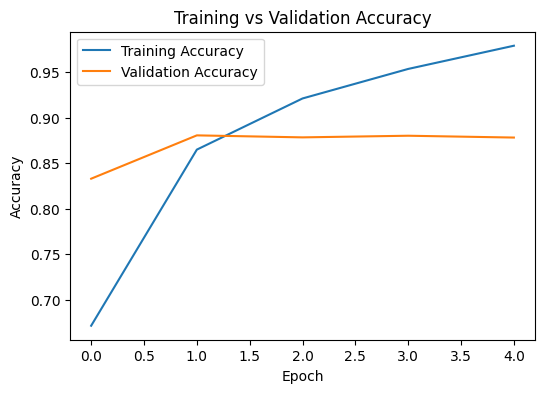

In [119]:
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

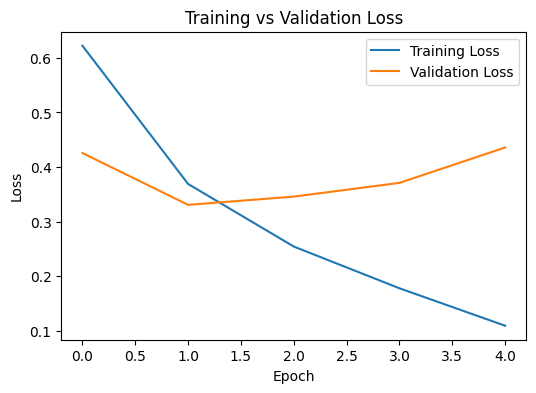

In [120]:
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [121]:
test_loss,test_accuracy=model.evaluate(X_test_padded,y_test,verbose=1)

print("Test Loss:",test_loss)
print(f"Test Accuracy: {test_accuracy:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.8801 - loss: 0.3265
Test Loss: 0.32654502987861633
Test Accuracy: 0.8801


#### Making predictions and thresholding for Regularized Model

In [122]:
y_pred_proba=model.predict(X_test_padded,batch_size=128)
y_pred=(y_pred_proba>0.5).astype(int).flatten()

196/196 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step


#### Evaluation metrics for Regularized Model

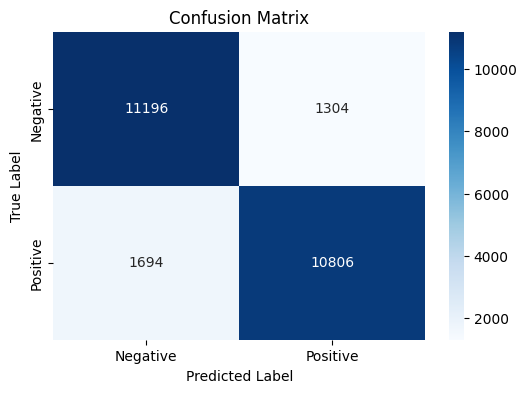

In [123]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm=confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['Negative','Positive'],yticklabels=['Negative','Positive'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [124]:
print(f"Precision Score: {precision_score(y_test,y_pred):.4f}")
print(f"Recall Score: {accuracy_score(y_test,y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test,y_pred):.4f}")

Precision Score: 0.8923
Recall Score: 0.8801
F1 Score: 0.8782
